In [19]:
from torch_geometric.datasets import AttributedGraphDataset
import torch_geometric.transforms as T
import os

# conver torch to list


dataset = AttributedGraphDataset(root=os.path.expanduser('~/pyg_data/AttributedGraphDataset'), name='CiteSeer', transform=T.ToUndirected())
data = dataset[0]

print(f"Dataset: AttributedGraphDataset - {dataset.name}")
print(f"Number of graphs: {len(dataset)}")
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Is directed: {not data.is_undirected()}")
print(f"Node feature shape: {data.x.shape}")
print(f"Node feature example (first node): {data.x[0]}")
# print(f"Unique values in features {unique_values_torch(data)}")
print(f"Number of node classes: {dataset.num_classes}")
print(f"Edge index shape: {data.edge_index.shape}")

Dataset: AttributedGraphDataset - citeseer
Number of graphs: 1
Number of nodes: 3312
Number of edges: 9196
Is directed: False
Node feature shape: torch.Size([3312, 3703])
Node feature example (first node): tensor([0., 0., 0.,  ..., 0., 0., 0.])
Number of node classes: 6
Edge index shape: torch.Size([2, 9196])


In [5]:
from load_real_network import load_real_graph
G, data, true_labels = load_real_graph(name='Wiki')
print(f"Real graph loaded:")
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Is directed: {not data.is_undirected()}")
print(f"Node feature shape: {data.x.shape}")
print(f"Node feature example (first node): {data.x[0]}")
print(f"Number of node classes: {len(set(true_labels))}")
print(f"Labels of communities: {set(true_labels)}")

Real graph loaded:
Number of nodes: 2405
Number of edges: 24357
Is directed: False
Node feature shape: torch.Size([2405, 4973])
Node feature example (first node): tensor([0., 0., 0.,  ..., 0., 0., 0.])
Number of node classes: 17
Labels of communities: {0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16}


In [6]:
isolates= 0
for node in G.nodes():
    if len(list(G.neighbors(node)))==0:
        isolates += 1
print(isolates)

import networkx as nx
# only show largest connected component
largest_cc = max(nx.connected_components(G), key=len)
print(G.nodes())
subgraph = G.subgraph(largest_cc)
print(f"Largest connected component has {len(subgraph)} nodes and {subgraph.number_of_edges()} edges.")

42
[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187, 188, 189, 190, 191, 192, 193, 194, 195, 196, 197, 198, 199, 200, 201, 202, 203, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 214, 215, 216, 217, 218, 219, 220, 2

In [12]:
import torch
from torch_geometric.utils import from_networkx
import time
import attacks  
import numpy as np

num_features = data.x.shape[1]
def train_model(data, true_labels, num_features=num_features):
    import dmon
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_clusters = len(set(true_labels))
    model = dmon.DMoN(
        in_channels=num_features, 
        num_clusters=num_clusters, 
        hidden_channels=128,
        num_layers=2, # default is 1 for shallow model or 2 for typical GCN
        dropout=0.5,  
        gcn_skip=True,
        collapse_regularization=1.0  
    ).to(device)
     
    optimizer = torch.optim.Adam(model.parameters(), lr=0.001, weight_decay=5e-4)
    
    for epoch in range(501):
        model.train()
        optimizer.zero_grad()
        ca, loss = model(data.x, data.edge_index)
        loss.backward()
        optimizer.step()
        if epoch % 20 == 0:
            print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")
    model.eval()
    with torch.no_grad():
        ca, _ = model(data.x, data.edge_index)
    pred_labels = ca.argmax(dim=1).cpu().numpy()
    return pred_labels

b_percentages = [0.01, 0.2, 0.5]
number_of_communities = len(set(true_labels))
print(f"Number of communities: {number_of_communities}")
pred_labels = train_model(data, true_labels)
ecs_initial = attacks.compute_ECS(true_labels, pred_labels)

from sklearn.metrics import normalized_mutual_info_score
nmi_initial = normalized_mutual_info_score(true_labels, pred_labels)
print(f"\n=== Initial Results (No Attack) ===")
print(f"NMI: {nmi_initial:.4f} | ECS: {ecs_initial:.4f}")

for target_label in set(true_labels):
    target_community = [nn for nn, label in enumerate(true_labels) if label == target_label]
    target_size = len(target_community)
    M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels)
    M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels)
    
    print(f"Target label {target_label} | Size: {target_size} | Initial ECS: {ecs_initial:.4f} | M1: {M1:.4f} | M2: {M2:.4f}")
    # Budget as % of intra-community edges
    G_target = G.subgraph(target_community)
    intra_edges = G_target.number_of_edges()
    for p in b_percentages:
        break
        bb = int(np.round(p * intra_edges))
        for realization in range(5):
            print(f"Realization {realization+1}/5 |label={target_label} b={bb}")
            start = time.time()
            G_attacked = attacks.dice_community_attack(G.copy(), target_community, bb)
            # G_attacked = attacks.dice_cfeature_node_attack(G.copy(), target_community, true_labels, S,  bb, p=p_val, feature_mode= args.attack_feature_mode)
            data_attacked = from_networkx(G_attacked)
            data_attacked.x = torch.stack([G_attacked.nodes[i]['x'] for i in range(len(G_attacked))])
            pred_labels_attacked = train_model(data_attacked, true_labels)
            ecs = attacks.compute_ECS(true_labels, pred_labels_attacked)
            M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels_attacked)
            M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels_attacked)
            elapsed_time = time.time() - start
            print(f"Post-attack ECS: {ecs:.4f} | M1: {M1:.4f} | M2: {M2:.4f} | Time: {elapsed_time:.2f} sec")
        print(f"Completed budget {p} for target label {target_label}")
        break  # only do one budget for testing


Number of communities: 17
Epoch 000 | Loss: 1.1991
Epoch 020 | Loss: 0.2115
Epoch 040 | Loss: -0.0644
Epoch 060 | Loss: -0.1414
Epoch 080 | Loss: -0.1226
Epoch 100 | Loss: -0.1171
Epoch 120 | Loss: -0.1428
Epoch 140 | Loss: -0.1379
Epoch 160 | Loss: -0.0996
Epoch 180 | Loss: -0.1538
Epoch 200 | Loss: -0.1406
Epoch 220 | Loss: -0.1646
Epoch 240 | Loss: -0.1694
Epoch 260 | Loss: -0.1451
Epoch 280 | Loss: -0.1425
Epoch 300 | Loss: -0.1614
Epoch 320 | Loss: -0.1629
Epoch 340 | Loss: -0.1315
Epoch 360 | Loss: -0.1672
Epoch 380 | Loss: -0.1716
Epoch 400 | Loss: -0.1715
Epoch 420 | Loss: -0.1731
Epoch 440 | Loss: -0.1474
Epoch 460 | Loss: -0.1614
Epoch 480 | Loss: -0.1425
Epoch 500 | Loss: -0.1661

=== Initial Results (No Attack) ===
NMI: 0.4497 | ECS: 0.3259
Target label 0 | Size: 92 | Initial ECS: 0.3259 | M1: 0.0312 | M2: 0.8971
Target label 1 | Size: 406 | Initial ECS: 0.3259 | M1: 0.0094 | M2: 0.8524
Target label 2 | Size: 203 | Initial ECS: 0.3259 | M1: 0.0035 | M2: 0.6217
Target label 

In [10]:
# from lfr_generator import visualize_lfr_graph

# labels_dict = {}
# for i, label in enumerate(true_labels):
#         labels_dict[i] = label
# visualize_lfr_graph(G, labels_dict, title=f"Wiki")

In [1]:
# testing the feature generation from communities
from lfr_generator import generate_features_from_communities
generate_features_from_communities(true_labels=[0, 1, 2, 3, 0, 2, 1, 1, 2, 3], 
                                   mode = 'gaussian', num_features=5, n_clusters_f=5)

array([[ 0.97125674, -0.76460365,  3.03460073,  0.61124548,  0.71385807],
       [-0.02347035, -1.90776535,  1.54931914, -2.94077968, -3.37411828],
       [-2.13268081, -1.18816213, -0.1601611 , -2.95068314, -2.79929842],
       [ 2.07711242, -0.32439875, -0.05932338, -1.26684347, -0.2444996 ],
       [ 0.68870531, -1.24856614, -0.46146476,  3.41166551, -0.9437072 ],
       [-2.32058867, -2.63486623, -0.58625996, -1.43831495, -1.86405897],
       [ 0.08508547,  0.08766473,  1.17408875, -3.52106448, -3.61112272],
       [-2.31081628,  0.29297938,  0.24135883, -3.7242819 , -1.80792898],
       [-1.87211851, -0.91947954,  0.84085373, -2.61057371, -2.52198551],
       [ 3.51154167,  0.40453944,  1.61239653, -2.12955499,  2.42939772]])

In [2]:
import attacks
true_labels = [0, 1, 2, 3, 0, 2, 1, 1, 2, 3]
target_list = [0, 1, 2, 4]
M1 = attacks.compute_M1(target_list=target_list, labels=true_labels)
print("M1 matrix:")
print(M1)

M1 matrix:
0.3333333333333333


In [3]:
import attacks
true_labels = [0, 1, 2, 3, 0, 2, 1, 1, 2, 3]
target_list = [0, 1, 2, 4]
M2 = attacks.compute_M2(target_list=target_list, labels=true_labels)
print("M2 matrix:")
print(M2)

M2 matrix:
0.6666666666666666


## LFR graph generation

In [6]:
import numpy as np
import random

import argparse
import os
import itertools
import csv
import networkx as nx
from lfr_generator import generate_featurized_lfr_graph, precompute_allpairs_neg_sqeuclidean, precompute_node_comm_neg_sqeuclidean


mu = 0.3
sigma_c = 0.1
min_community = 10
seed = 42
n = 1000
results_dir = "f_graphs-dice"
os.makedirs(results_dir, exist_ok=True)
# === Generate graph ===
print(f"Generating graphs with mu={mu}, sigma_c={sigma_c}")
G, data, true_labels = generate_featurized_lfr_graph(
    mu=mu, n=n, min_community=min_community,
    feature_mode='gaussian', sigma_c=sigma_c, seed=seed)
# Precompute pairwise similarities for feature-based attacks
# _, S = precompute_allpairs_neg_sqeuclidean(G)
# _, S_nc = precompute_node_comm_neg_sqeuclidean(G, true_labels)
# === Save graph and membership ===
base_name = f"graph_n{n}_mu{mu}_sigma{sigma_c}_min_comm{min_community}"

graph_file = os.path.join(results_dir, base_name + ".edgelist")
membership_file = os.path.join(results_dir, base_name + ".membership")
# Save the graph as an edge list
nx.write_edgelist(G, graph_file, delimiter=' ', data=True)
# Save the membership as a 1D array (each line: community ID)
np.savetxt(membership_file, true_labels, delimiter=' ', fmt='%d')
# === Save features ===
features_file = os.path.join(results_dir, base_name + ".features")
with open(features_file, "w", newline="") as f:
    writer = csv.writer(f, delimiter=' ')
    for node, data in G.nodes(data=True):
        # Ensure feature is NumPy array of floats
        x = data['x']
        if isinstance(x, torch.Tensor):
            x = x.detach().cpu().numpy()
        row = [node] + list(map(float, x))
        writer.writerow(row)


Generating graphs with mu=0.3, sigma_c=0.1


In [ ]:
import numpy as np
import torch

@torch.inference_mode()
def precompute_allpairs_neg_sqeuclidean_from_features_file(
    features_file,
    device=None,
    dtype=torch.float32,
    nodetype=int,        # change to str if your node ids are strings
):
    """
    Reads <node_id feat1 feat2 ...> per line and returns:
      nodes : list[node_id] in the file's order
      idx_of: dict[node_id] -> row index
      F     : (N,D) feature tensor on `device`
      S     : (N,N) NEG squared Euclidean similarity (diag = -inf)
    """
    device = device or ("cuda" if torch.cuda.is_available() else "cpu")

    nodes, feats = [], []
    with open(features_file, "r") as f:
        for line in f:
            parts = line.strip().split()
            if not parts:
                continue
            nid = nodetype(parts[0])
            x = np.asarray([float(v) for v in parts[1:]], dtype=np.float32)
            nodes.append(nid)
            feats.append(x)

    F = torch.as_tensor(np.stack(feats), dtype=dtype, device=device).contiguous()
    idx_of = {n: i for i, n in enumerate(nodes)}

    X2 = (F * F).sum(dim=1, keepdim=True)
    S = (X2 + X2.T - 2.0 * (F @ F.T)).clamp_min_(0).neg_()
    S.fill_diagonal_(-float("inf"))
    return nodes, idx_of, F, S

nodes, idx_of, F, S = precompute_allpairs_neg_sqeuclidean_from_features_file(
    "f_graphs-dice/graph_n1000_mu0.3_sigma0.1_min_comm10.features",
    nodetype=int
)
print("Feature matrix F shape:", F.shape)
print("Similarity matrix S shape:", S.shape)

Feature matrix F shape: torch.Size([1000, 32])
Similarity matrix S shape: torch.Size([1000, 1000])


In [1]:
from lfr_generator import generate_featurized_lfr_graph
import random
from tqdm import tqdm
import numpy as np

sigma_c_values = [0.01, 0.1, 0.5, 1, 2, 5, 10]
mu_values = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5]
realizations = 1
n = 1000  # Number of nodes in the graph
b_percentage = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1] # % Budget for the DICE attack
# random.seed(42)  # For reproducibility
realizations = 10  # Number of realizations for each parameter combination
nodes_per_community = {}
min_community = 10  # Minimum community size

for mu in mu_values:
    for sigma_c in sigma_c_values:
        print(f"Generating graphs with mu={mu}, sigma_c={sigma_c}")
        G, data, true_labels = generate_featurized_lfr_graph(
            mu=mu, n=n,
            min_community=min_community,  # Minimum community size
            feature_mode='gaussian', sigma_c=sigma_c, 
            seed=42
        )
        print(f"Generated graph with {G.number_of_nodes()} nodes and {G.number_of_edges()} edges")
        number_of_communities = len(set(true_labels))
        print(f"Number of communities: {number_of_communities}")
        for community in set(true_labels):
            # print(f"Community {community} has {list(true_labels).count(community)} nodes")
            if community not in nodes_per_community:
                nodes_per_community[community] = [list(true_labels).count(community)]
            else:
                nodes_per_community[community] += [list(true_labels).count(community)]
            # for b in b_percentage:
            #     print(f"{b*100} % budget of community {community} nodes = {int(b * list(true_labels).count(community))}")
for community, counts in nodes_per_community.items():
    print(f"Community {community} has {np.mean(counts)} realizations with node counts: {counts}")


Generating graphs with mu=0.01, sigma_c=0.01
Generated graph with 1000 nodes and 17022 edges
Number of communities: 25
Generating graphs with mu=0.01, sigma_c=0.1
Generated graph with 1000 nodes and 17022 edges
Number of communities: 25
Generating graphs with mu=0.01, sigma_c=0.5
Generated graph with 1000 nodes and 17022 edges
Number of communities: 25
Generating graphs with mu=0.01, sigma_c=1
Generated graph with 1000 nodes and 17022 edges
Number of communities: 25
Generating graphs with mu=0.01, sigma_c=2
Generated graph with 1000 nodes and 17022 edges
Number of communities: 25
Generating graphs with mu=0.01, sigma_c=5
Generated graph with 1000 nodes and 17022 edges
Number of communities: 25
Generating graphs with mu=0.01, sigma_c=10
Generated graph with 1000 nodes and 17022 edges
Number of communities: 25
Generating graphs with mu=0.1, sigma_c=0.01
Generated graph with 1000 nodes and 17448 edges
Number of communities: 25
Generating graphs with mu=0.1, sigma_c=0.1
Generated graph wit

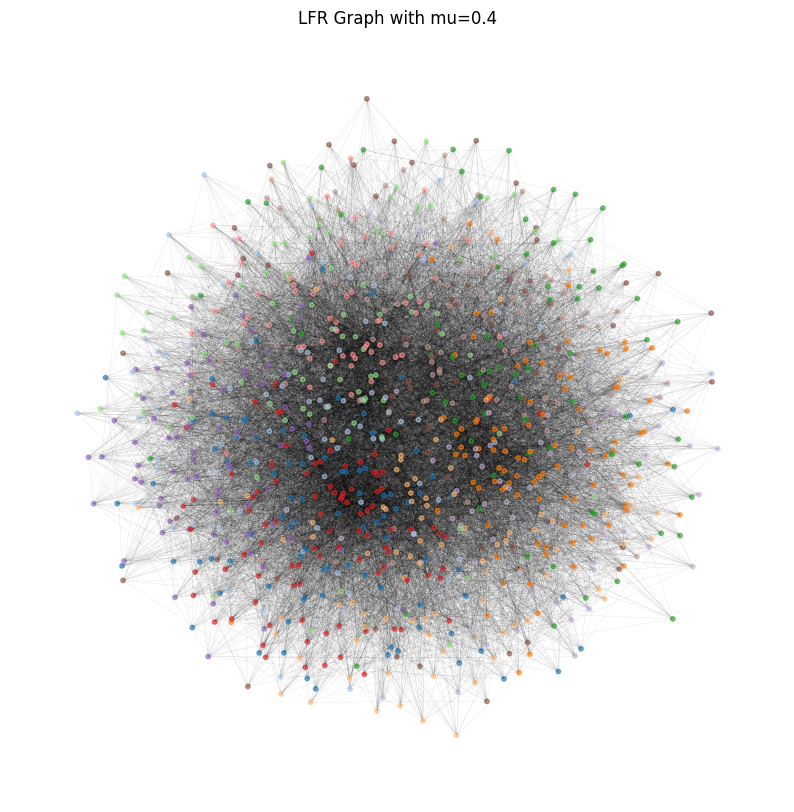

In [1]:
from lfr_generator import visualize_lfr_graph
from lfr_generator import generate_featurized_lfr_graph
mu= 0.4
G, data, true_labels = generate_featurized_lfr_graph(
            mu=mu, n=1000,
            min_community = 60,  # Minimum community size
            feature_mode='gaussian', sigma_c=1, 
            seed=7
        )
labels_dict = {}
for i, label in enumerate(true_labels):
        labels_dict[i] = label
visualize_lfr_graph(G, labels_dict, title=f"LFR Graph with mu={mu}")


In [2]:
list(G.nodes())

[0,
 1,
 2,
 3,
 4,
 5,
 6,
 7,
 8,
 9,
 10,
 11,
 12,
 13,
 14,
 15,
 16,
 17,
 18,
 19,
 20,
 21,
 22,
 23,
 24,
 25,
 26,
 27,
 28,
 29,
 30,
 31,
 32,
 33,
 34,
 35,
 36,
 37,
 38,
 39,
 40,
 41,
 42,
 43,
 44,
 45,
 46,
 47,
 48,
 49,
 50,
 51,
 52,
 53,
 54,
 55,
 56,
 57,
 58,
 59,
 60,
 61,
 62,
 63,
 64,
 65,
 66,
 67,
 68,
 69,
 70,
 71,
 72,
 73,
 74,
 75,
 76,
 77,
 78,
 79,
 80,
 81,
 82,
 83,
 84,
 85,
 86,
 87,
 88,
 89,
 90,
 91,
 92,
 93,
 94,
 95,
 96,
 97,
 98,
 99,
 100,
 101,
 102,
 103,
 104,
 105,
 106,
 107,
 108,
 109,
 110,
 111,
 112,
 113,
 114,
 115,
 116,
 117,
 118,
 119,
 120,
 121,
 122,
 123,
 124,
 125,
 126,
 127,
 128,
 129,
 130,
 131,
 132,
 133,
 134,
 135,
 136,
 137,
 138,
 139,
 140,
 141,
 142,
 143,
 144,
 145,
 146,
 147,
 148,
 149,
 150,
 151,
 152,
 153,
 154,
 155,
 156,
 157,
 158,
 159,
 160,
 161,
 162,
 163,
 164,
 165,
 166,
 167,
 168,
 169,
 170,
 171,
 172,
 173,
 174,
 175,
 176,
 177,
 178,
 179,
 180,
 181,
 182,
 183,
 184,


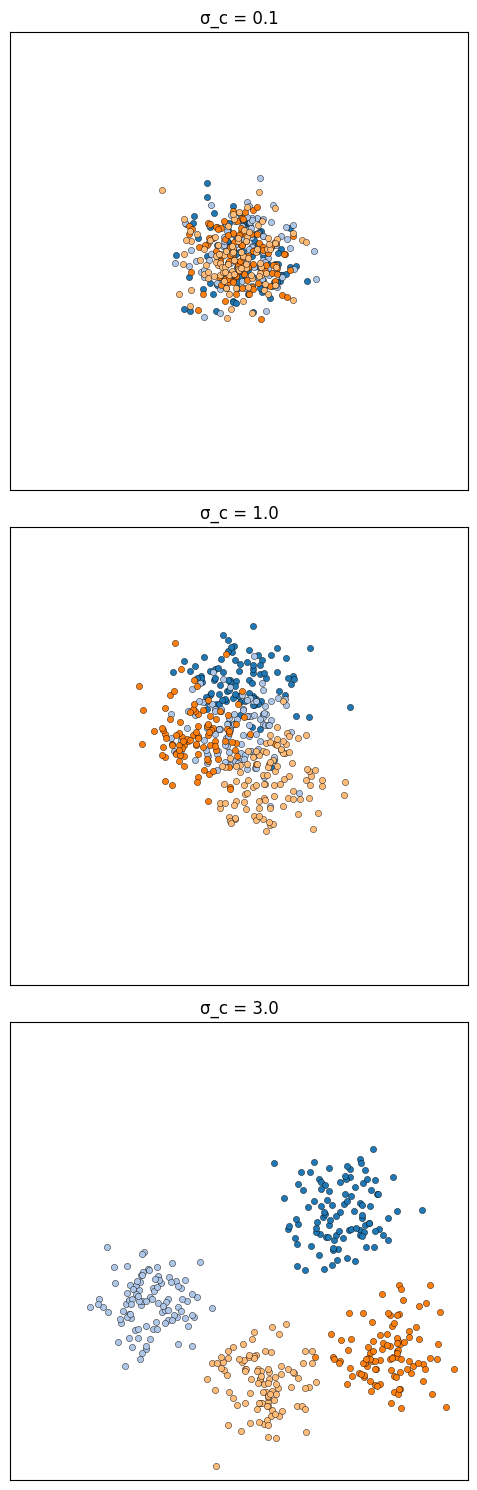

In [46]:
import numpy as np
import matplotlib.pyplot as plt

def plot_feature_clusters(sigmas, n_clusters=4, points_per_cluster=100, seed=0):
    rng = np.random.default_rng()
    fig, axes = plt.subplots(len(sigmas), 1, figsize=(5, 5 * len(sigmas)))
    
    # Pre-generate all data to compute global bounds
    all_data = []
    for sigma_c in sigmas:
        centroids = rng.multivariate_normal(
            mean=np.zeros(2),
            cov=(sigma_c**2) * np.eye(2),
            size=n_clusters
        )
        pts_list, labels_list = [], []
        for cluster_idx, mu in enumerate(centroids):
            pts = rng.multivariate_normal(
                mean=mu,
                cov=np.eye(2),
                size=points_per_cluster
            )
            pts_list.append(pts)
            labels_list.append(np.full(points_per_cluster, cluster_idx))
        all_data.append((np.vstack(pts_list), np.concatenate(labels_list)))
    all_pts = np.vstack([d[0] for d in all_data])
    lo, hi = all_pts.min() - 0.5, all_pts.max() + 0.5

    cmap = plt.get_cmap('tab20')
    
    for ax, ((pts, labels), sigma_c) in zip(axes, zip(all_data, sigmas)):
        for cluster_idx in range(n_clusters):
            ax.scatter(
                pts[labels == cluster_idx, 0],
                pts[labels == cluster_idx, 1],
                color=cmap(cluster_idx),
                s=20,
                edgecolor='k',
                linewidth=0.3
            )
        ax.set_xlim(lo, hi)
        ax.set_ylim(lo, hi)
        ax.set_aspect('equal', 'box')
        ax.set_title(f"σ_c = {sigma_c}")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(False)

    plt.tight_layout()
    plt.show()

# Usage example
plot_feature_clusters(sigmas=[0.1, 1.0, 3.0], n_clusters=4, points_per_cluster=100)


In [14]:
G, data, true_labels = generate_featurized_lfr_graph(
            mu=0.01, n=1000,
            min_community = 10,  # Minimum community size
            feature_mode='gaussian', sigma_c=1, 
            seed=42
        )
target_label = 0
target_community = [nn for nn, label in enumerate(true_labels) if label == target_label]
pred_labels = train_model(data, true_labels)
ecs_initial = attacks.compute_ECS(true_labels, pred_labels)
nmi = normalized_mutual_info_score(true_labels, pred_labels)
target_size = len(target_community)
M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels)
M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels)
print(f"Initial ECS: {ecs_initial}, NMI: {nmi}")
print(f"Initial M1: {M1}, M2: {M2}")
G_attacked = attacks.dice_community_attack(G.copy(), 0, bb)

NameError: name 'generate_featurized_lfr_graph' is not defined

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm
import random
import torch
import networkx as nx
from lfr_generator import generate_featurized_lfr_graph
import attacks
from torch_geometric.utils import from_networkx
from sklearn.metrics import normalized_mutual_info_score
import time

def train_model(data, true_labels, num_features=32):
    import dmon
    
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

    num_clusters = len(set(true_labels))
    model = dmon.DMoN(in_channels=num_features, num_clusters=num_clusters, gcn_skip=True).to(device)
    # model = dmon.DMoN(in_channels=num_features, num_clusters=num_clusters, gcn_skip=True)
    optimizer = torch.optim.Adam(model.parameters(), lr=0.005, weight_decay=5e-4)
    data = data.to(device)  # send features and edges to GPU
    for epoch in range(201):
        model.train()
        optimizer.zero_grad()
        ca, loss = model(data.x, data.edge_index)
        loss.backward()
        optimizer.step()
        # if epoch % 20 == 0:
        #     print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")
    model.eval()
    data = data.to(device)  # ensure data is on same device for eval
    ca, _ = model(data.x, data.edge_index)
    pred_labels = ca.argmax(dim=1).cpu().numpy()  # bring prediction back to CPU
    return pred_labels

num_features =  32
sigma_c_values = [1]
# mu_values = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5]
mu_values = [0.01, 0.1, 0.2]
realizations = 1
n = 1000  # Number of nodes in the graph
b_percentages = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5] # % Budget for the DICE attack
seed = 42  # For reproducibility
min_community = 10  # Minimum community size

results = {}  # {mu: {sigma_c: {b: {DICE: {"nmi": [], "ecs": [], "M1": [], "M2": []}}}}}

for mu in tqdm(mu_values, desc="mu values"):
    results[mu] = {}
    for sigma_c in sigma_c_values:
        print(f"Generating graphs for mu={mu}, sigma_c={sigma_c}")
        results[mu][sigma_c] = {p: {"DICE": {"nmi": [], "ecs": [], "M1": [], "M2": []}, 
                                    "DICEHDG": {"nmi": [], "ecs": [], "M1": [], "M2": []}, 
                                    "DICEHDGCD": {"nmi": [], "ecs": [], "M1": [], "M2": []},
                                    "DICECDHD": {"nmi": [], "ecs": [], "M1": [], "M2": []},
                                    "DICECDHC": {"nmi": [], "ecs": [], "M1": [], "M2": []}} for p in b_percentages}
        results[mu][sigma_c][0] = {"DICE": {"nmi": [], "ecs": [], "M1": [], "M2": []}, 
                                   "DICEHDG": {"nmi": [], "ecs": [], "M1": [], "M2": []}, 
                                   "DICEHDGCD": {"nmi": [], "ecs": [], "M1": [], "M2": []},
                                   "DICECDHD": {"nmi": [], "ecs": [], "M1": [], "M2": []},
                                   "DICECDHC": {"nmi": [], "ecs": [], "M1": [], "M2": []}}
        G, data, true_labels = generate_featurized_lfr_graph(
                mu=mu, n=n, min_community=min_community,
                feature_mode='gaussian', sigma_c=sigma_c, seed=seed)
        number_of_communities = len(set(true_labels))
        print(f"Number of communities: {number_of_communities}")
        pred_labels = train_model(data, true_labels)
        ecs_initial = attacks.compute_ECS(true_labels, pred_labels)
        nmi = normalized_mutual_info_score(true_labels, pred_labels)
        for target_label in set(true_labels):
            if target_label == 0:
                target_community = [nn for nn, label in enumerate(true_labels) if label == target_label]
                target_size = len(target_community)
                M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels)
                M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels)
                # Store results for the original graph
                results[mu][sigma_c][0]['DICE']["nmi"].append(nmi)
                results[mu][sigma_c][0]['DICE']["ecs"].append(ecs_initial)
                results[mu][sigma_c][0]['DICE']["M1"].append(M1)
                results[mu][sigma_c][0]['DICE']["M2"].append(M2)

                results[mu][sigma_c][0]['DICEHDG']["nmi"].append(nmi)
                results[mu][sigma_c][0]['DICEHDG']["ecs"].append(ecs_initial)
                results[mu][sigma_c][0]['DICEHDG']["M1"].append(M1)
                results[mu][sigma_c][0]['DICEHDG']["M2"].append(M2)

                results[mu][sigma_c][0]['DICEHDGCD']["nmi"].append(nmi)
                results[mu][sigma_c][0]['DICEHDGCD']["ecs"].append(ecs_initial)
                results[mu][sigma_c][0]['DICEHDGCD']["M1"].append(M1)
                results[mu][sigma_c][0]['DICEHDGCD']["M2"].append(M2)

                results[mu][sigma_c][0]['DICECDHD']["nmi"].append(nmi)
                results[mu][sigma_c][0]['DICECDHD']["ecs"].append(ecs_initial)
                results[mu][sigma_c][0]['DICECDHD']["M1"].append(M1)
                results[mu][sigma_c][0]['DICECDHD']["M2"].append(M2)

                results[mu][sigma_c][0]['DICECDHC']["nmi"].append(nmi)
                results[mu][sigma_c][0]['DICECDHC']["ecs"].append(ecs_initial)
                results[mu][sigma_c][0]['DICECDHC']["M1"].append(M1)
                results[mu][sigma_c][0]['DICECDHC']["M2"].append(M2)

                # Budget as % of intra-community edges
                G_target = G.subgraph(target_community)
                intra_edges = G_target.number_of_edges()
                for p in b_percentages:
                    bb = int(np.round(p * intra_edges))
                    for realization in range(realizations):
                        print(f"Applying DICE attack with budget {bb} on target community {target_label}")
                        # print(f"Realization {realization+1}/{realizations} | mu={mu} sigma_c={sigma_c} label={target_label} b={bb}")
                        start = time.time()
                        # Normal DICE
                        G_attacked = attacks.dice_community_attack(G.copy(), target_community, bb)
                        data_attacked = from_networkx(G_attacked)
                        data_attacked.x = torch.stack([G_attacked.nodes[i]['x'] for i in range(len(G_attacked))])
                        pred_labels_attacked = train_model(data_attacked, true_labels)

                        nmi = normalized_mutual_info_score(true_labels, pred_labels_attacked)
                        ecs = attacks.compute_ECS(true_labels, pred_labels_attacked)
                        M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels_attacked)
                        M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels_attacked)
                        elapsed_time = time.time() - start
                        results[mu][sigma_c][p]['DICE']["nmi"].append(nmi)
                        results[mu][sigma_c][p]['DICE']["ecs"].append(ecs)
                        results[mu][sigma_c][p]['DICE']["M1"].append(M1)
                        results[mu][sigma_c][p]['DICE']["M2"].append(M2)

                        # DICE with attachment to high degree global
                        G_attacked_hd_global = attacks.dicehd_community_attack(G.copy(), target_community, bb)
                        data_attacked_hd_global = from_networkx(G_attacked_hd_global)
                        data_attacked_hd_global.x = torch.stack([G_attacked_hd_global.nodes[i]['x'] for i in range(len(G_attacked_hd_global))])
                        pred_labels_attacked_hd_global = train_model(data_attacked_hd_global, true_labels)

                        nmi_hd_global = normalized_mutual_info_score(true_labels, pred_labels_attacked_hd_global)
                        ecs_hd_global = attacks.compute_ECS(true_labels, pred_labels_attacked_hd_global)
                        M1_hd_global = attacks.compute_M1(target_list=target_community, labels=pred_labels_attacked_hd_global)
                        M2_hd_global = attacks.compute_M2(target_list=target_community, labels=pred_labels_attacked_hd_global)

                        results[mu][sigma_c][p]['DICEHDG']["nmi"].append(nmi_hd_global)
                        results[mu][sigma_c][p]['DICEHDG']["ecs"].append(ecs_hd_global)
                        results[mu][sigma_c][p]['DICEHDG']["M1"].append(M1_hd_global)
                        results[mu][sigma_c][p]['DICEHDG']["M2"].append(M2_hd_global)

                        # DICE with attachment to high degree global from other communities
                        G_attacked_hdcd = attacks.dicehdcd_community_attack(G.copy(), target_community, true_labels, bb)
                        data_attacked_hdcd = from_networkx(G_attacked_hdcd)
                        data_attacked_hdcd.x = torch.stack([G_attacked_hdcd.nodes[i]['x'] for i in range(len(G_attacked_hdcd))])
                        pred_labels_attacked_hdcd = train_model(data_attacked_hdcd, true_labels)

                        nmi_hdcd = normalized_mutual_info_score(true_labels, pred_labels_attacked_hdcd)
                        ecs_hdcd = attacks.compute_ECS(true_labels, pred_labels_attacked_hdcd)
                        M1_hdcd = attacks.compute_M1(target_list=target_community, labels=pred_labels_attacked_hdcd)
                        M2_hdcd = attacks.compute_M2(target_list=target_community, labels=pred_labels_attacked_hdcd)

                        results[mu][sigma_c][p]['DICEHDGCD']["nmi"].append(nmi_hdcd)
                        results[mu][sigma_c][p]['DICEHDGCD']["ecs"].append(ecs_hdcd)
                        results[mu][sigma_c][p]['DICEHDGCD']["M1"].append(M1_hdcd)
                        results[mu][sigma_c][p]['DICEHDGCD']["M2"].append(M2_hdcd)

                        # DICE with attachment to high degree local from other communities
                        G_attacked_cdhd = attacks.dicecdhd_community_attack(G.copy(), target_community, true_labels, bb)
                        data_attacked_cdhd = from_networkx(G_attacked_cdhd)
                        data_attacked_cdhd.x = torch.stack([G_attacked_cdhd.nodes[i]['x'] for i in range(len(G_attacked_cdhd))])
                        pred_labels_attacked_cdhd = train_model(data_attacked_cdhd, true_labels)

                        nmi_cdhd = normalized_mutual_info_score(true_labels, pred_labels_attacked_cdhd)
                        ecs_cdhd = attacks.compute_ECS(true_labels, pred_labels_attacked_cdhd)
                        M1_cdhd = attacks.compute_M1(target_list=target_community, labels=pred_labels_attacked_cdhd)
                        M2_cdhd = attacks.compute_M2(target_list=target_community, labels=pred_labels_attacked_cdhd)

                        results[mu][sigma_c][p]['DICECDHD']["nmi"].append(nmi_cdhd)
                        results[mu][sigma_c][p]['DICECDHD']["ecs"].append(ecs_cdhd)
                        results[mu][sigma_c][p]['DICECDHD']["M1"].append(M1_cdhd)
                        results[mu][sigma_c][p]['DICECDHD']["M2"].append(M2_cdhd)

                        # DICE with attachment to high clustering nodes local from other communities
                        G_attacked_cdhc = attacks.dicecdhc_community_attack(G.copy(), target_community, true_labels, bb)
                        data_attacked_cdhc = from_networkx(G_attacked_cdhc)
                        data_attacked_cdhc.x = torch.stack([G_attacked_cdhc.nodes[i]['x'] for i in range(len(G_attacked_cdhc))])
                        pred_labels_attacked_cdhc = train_model(data_attacked_cdhc, true_labels)

                        nmi_cdhc = normalized_mutual_info_score(true_labels, pred_labels_attacked_cdhc)
                        ecs_cdhc = attacks.compute_ECS(true_labels, pred_labels_attacked_cdhc)
                        M1_cdhc = attacks.compute_M1(target_list=target_community, labels=pred_labels_attacked_cdhc)
                        M2_cdhc = attacks.compute_M2(target_list=target_community, labels=pred_labels_attacked_cdhc)

                        results[mu][sigma_c][p]['DICECDHC']["nmi"].append(nmi_cdhc)
                        results[mu][sigma_c][p]['DICECDHC']["ecs"].append(ecs_cdhc)
                        results[mu][sigma_c][p]['DICECDHC']["M1"].append(M1_cdhc)
                        results[mu][sigma_c][p]['DICECDHC']["M2"].append(M2_cdhc)
                        elapsed_time = time.time() - start

                    print(f"Completed budget {p} for target label {target_label} with elapsed time {elapsed_time:.2f} seconds")


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/threadpoolctl.py:1214: RuntimeWarning: 
Found Intel OpenMP ('libiomp') and LLVM OpenMP ('libomp') loaded at
the same time. Both libraries are known to be incompatible and this
can cause random crashes or deadlocks on Linux when loaded in the
same Python program.
Using threadpoolctl may cause crashes or deadlocks. For more
information and possible workarounds, please see
    https://github.com/joblib/threadpoolctl/blob/master/multiple_openmp.md

  warnings.warn(msg, RuntimeWarning)
mu values:   0%|          | 0/3 [00:00<?, ?it/s]

Generating graphs for mu=0.01, sigma_c=1
Number of communities: 25
Applying DICE attack with budget 1 on target community 0
Completed budget 0.01 for target label 0 with elapsed time 20.52 seconds
Applying DICE attack with budget 5 on target community 0
Completed budget 0.05 for target label 0 with elapsed time 18.94 seconds
Applying DICE attack with budget 10 on target community 0
Completed budget 0.1 for target label 0 with elapsed time 19.32 seconds
Applying DICE attack with budget 19 on target community 0
Completed budget 0.2 for target label 0 with elapsed time 19.23 seconds
Applying DICE attack with budget 29 on target community 0
Completed budget 0.3 for target label 0 with elapsed time 19.99 seconds
Applying DICE attack with budget 39 on target community 0
Completed budget 0.4 for target label 0 with elapsed time 18.97 seconds
Applying DICE attack with budget 48 on target community 0


mu values:  33%|███▎      | 1/3 [02:21<04:42, 141.14s/it]

Completed budget 0.5 for target label 0 with elapsed time 20.07 seconds
Generating graphs for mu=0.1, sigma_c=1
Number of communities: 25
Applying DICE attack with budget 1 on target community 0
Completed budget 0.01 for target label 0 with elapsed time 16.98 seconds
Applying DICE attack with budget 7 on target community 0
Completed budget 0.05 for target label 0 with elapsed time 17.76 seconds
Applying DICE attack with budget 14 on target community 0
Completed budget 0.1 for target label 0 with elapsed time 16.79 seconds
Applying DICE attack with budget 29 on target community 0
Completed budget 0.2 for target label 0 with elapsed time 18.09 seconds
Applying DICE attack with budget 43 on target community 0
Completed budget 0.3 for target label 0 with elapsed time 18.89 seconds
Applying DICE attack with budget 57 on target community 0
Completed budget 0.4 for target label 0 with elapsed time 18.75 seconds
Applying DICE attack with budget 72 on target community 0


mu values:  67%|██████▋   | 2/3 [04:30<02:14, 134.45s/it]

Completed budget 0.5 for target label 0 with elapsed time 18.62 seconds
Generating graphs for mu=0.2, sigma_c=1
Number of communities: 25
Applying DICE attack with budget 3 on target community 0
Completed budget 0.01 for target label 0 with elapsed time 19.32 seconds
Applying DICE attack with budget 13 on target community 0
Completed budget 0.05 for target label 0 with elapsed time 17.89 seconds
Applying DICE attack with budget 25 on target community 0
Completed budget 0.1 for target label 0 with elapsed time 19.33 seconds
Applying DICE attack with budget 51 on target community 0
Completed budget 0.2 for target label 0 with elapsed time 19.02 seconds
Applying DICE attack with budget 76 on target community 0
Completed budget 0.3 for target label 0 with elapsed time 20.81 seconds
Applying DICE attack with budget 102 on target community 0
Completed budget 0.4 for target label 0 with elapsed time 24.30 seconds
Applying DICE attack with budget 127 on target community 0


mu values: 100%|██████████| 3/3 [06:59<00:00, 139.70s/it]

Completed budget 0.5 for target label 0 with elapsed time 23.56 seconds


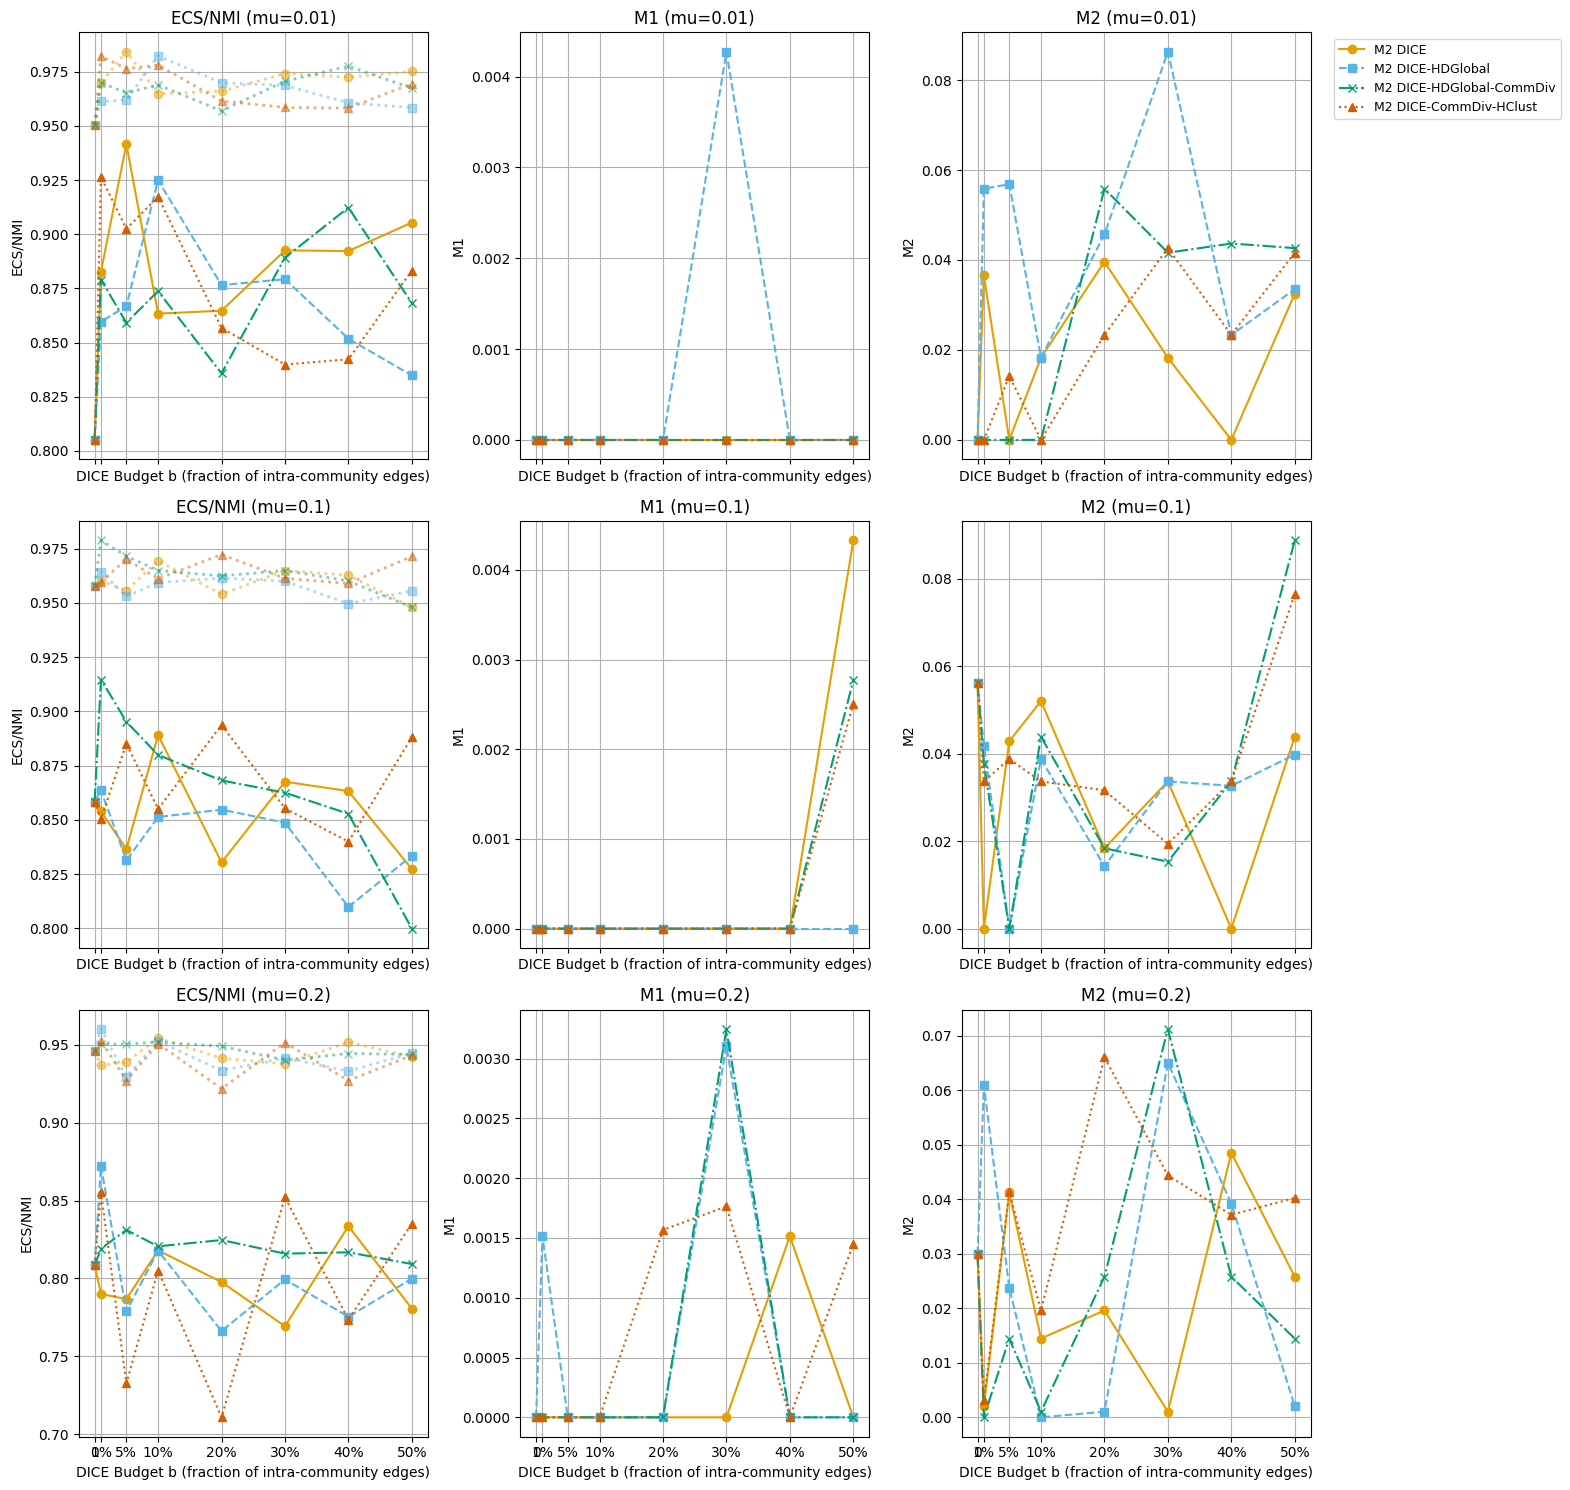

In [2]:
import matplotlib.pyplot as plt
import numpy as np

sigma_c_values = [1]
mu_values = [0.01, 0.1, 0.2]
b_percentages = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
all_p = [0] + b_percentages

attacks = ['DICE', 'DICEHDG', 'DICEHDGCD', 'DICECDHC']
attack_labels = {
    'DICE': 'DICE',
    'DICEHDG': 'DICE-HDGlobal',
    'DICEHDGCD': 'DICE-HDGlobal-CommDiv',
    'DICECDHC': 'DICE-CommDiv-HClust'
}

# Colorblind-friendly palette (Jfly CUD)
attack_colors = {
    'DICE': "#E69F00",
    'DICEHDG': "#56B4E9",
    'DICEHDGCD': "#009E73",
    'DICECDHC': "#D55E00"
}
attack_markers = {
    'DICE': 'o',
    'DICEHDG': 's',
    'DICEHDGCD': 'x',
    'DICECDHC': '^'
}
attack_linestyles = {
    'DICE': '-',
    'DICEHDG': '--',
    'DICEHDGCD': '-.',
    'DICECDHC': ':'
}

metrics = ['ecs', 'nmi', 'M1', 'M2']
metric_titles = ['ECS/NMI', 'M1', 'M2']

fig, axes = plt.subplots(len(mu_values), 3, figsize=(18, 5 * len(mu_values)), sharex=True)

for idx, mu in enumerate(mu_values):
    for attack in attacks:
        color = attack_colors[attack]
        marker = attack_markers[attack]
        linestyle = attack_linestyles[attack]

        for sigma_c in sigma_c_values:
            # --- Column 0: ECS and NMI ---
            ecs_means = [np.mean(results[mu][sigma_c][p][attack]["ecs"]) for p in all_p]
            nmi_means = [np.mean(results[mu][sigma_c][p][attack]["nmi"]) for p in all_p]
            # ECS line
            axes[idx, 0].plot(
                all_p, ecs_means, marker=marker, linestyle=linestyle,
                color=color, label=f"ECS {attack_labels[attack]}"
            )
            # NMI as dotted line, same color, faded
            axes[idx, 0].plot(
                all_p, nmi_means, marker=marker, linestyle='dotted', linewidth=2,
                color=color, alpha=0.5, label=f"NMI {attack_labels[attack]}"
            )

            # --- Column 1: M1 ---
            M1_means = [np.mean(results[mu][sigma_c][p][attack]["M1"]) for p in all_p]
            axes[idx, 1].plot(
                all_p, M1_means, marker=marker, linestyle=linestyle,
                color=color, label=f"M1 {attack_labels[attack]}"
            )

            # --- Column 2: M2 ---
            M2_means = [np.mean(results[mu][sigma_c][p][attack]["M2"]) for p in all_p]
            axes[idx, 2].plot(
                all_p, M2_means, marker=marker, linestyle=linestyle,
                color=color, label=f"M2 {attack_labels[attack]}"
            )

    for col, metric in enumerate(metric_titles):
        ax = axes[idx, col] if len(mu_values) > 1 else axes[col]
        ax.set_xlabel("DICE Budget b (fraction of intra-community edges)")
        ax.set_xticks(all_p)
        ax.set_xticklabels([f"{int(p*100)}%" if p != 0 else "0" for p in all_p])
        ax.set_ylabel(metric)
        ax.set_title(f"{metric} (mu={mu})")
        ax.grid(True)
        if idx == 0 and col == 2:
            # Only show legend once, outside right
            ax.legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)

plt.tight_layout(rect=[0, 0, 0.88, 1])
plt.show()


In [18]:
import pickle

with open('dmon_attack_results.pkl', 'wb') as f:
    pickle.dump(results, f)
print("Results saved to dmon_attack_results.pkl")


Results saved to dmon_attack_results.pkl


In [38]:
import pickle
with open('dmon_attack_results.pkl', 'rb') as f:
    results = pickle.load(f)


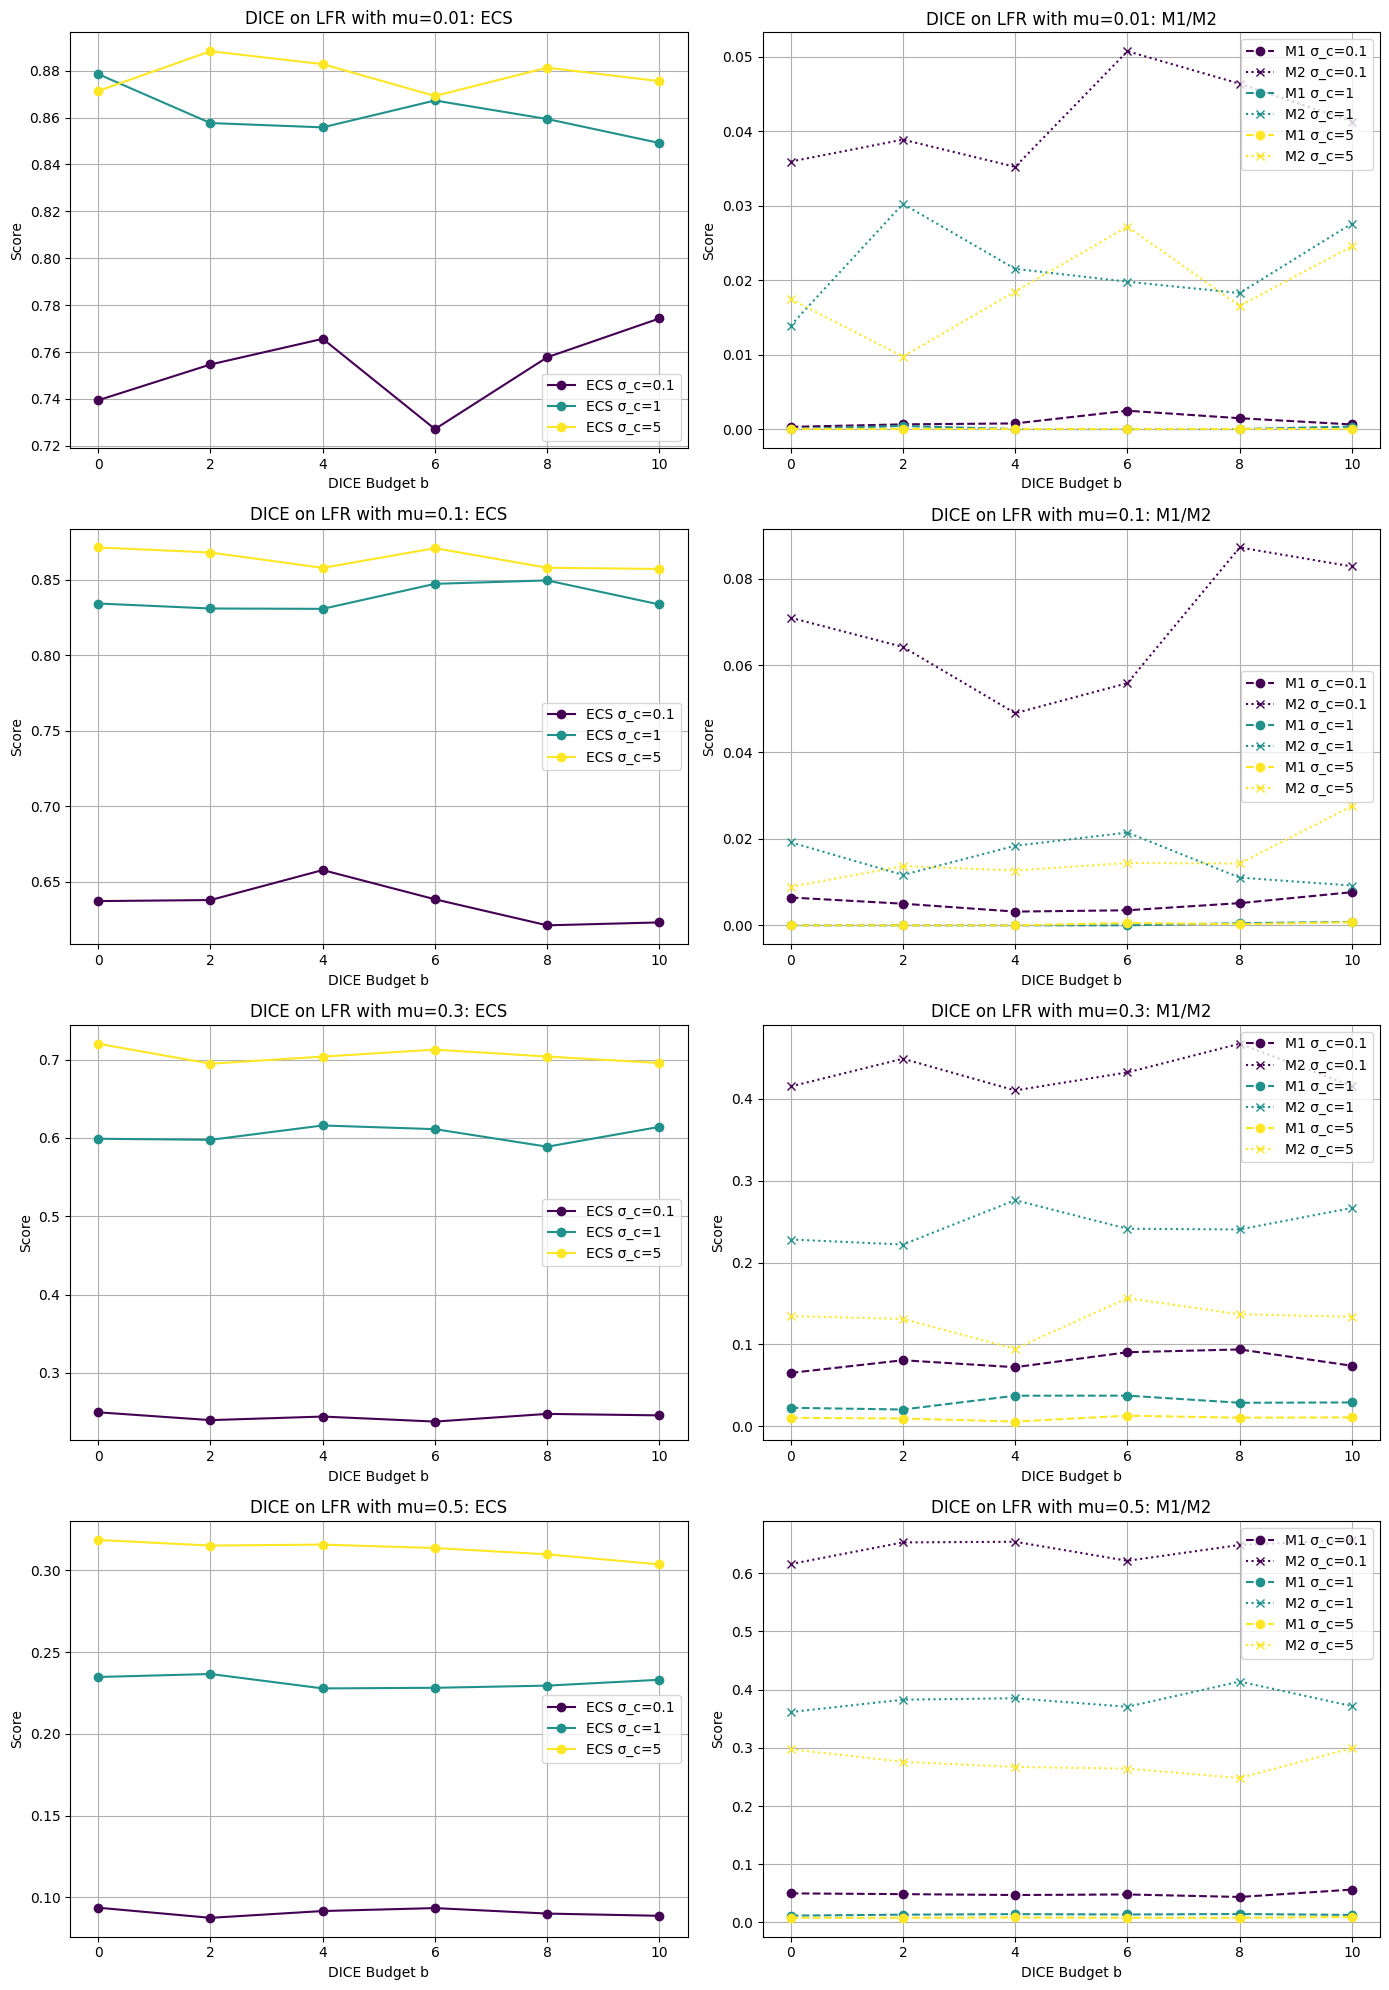

In [ ]:
import matplotlib.pyplot as plt
import matplotlib

num_features = 16
sigma_c_values = [0.1, 1, 5]
# mu_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
mu_values = [0.01, 0.1, 0.3,  0.5]
realizations = 10
n = 1000
b_values = [2, 4, 6, 8, 10]
target_label = 0
random.seed(42)  # For reproducibility
# Define colors for each sigma_c value, so colors are consistent across subplots
color_map = {s: c for s, c in zip(sigma_c_values, plt.cm.viridis(np.linspace(0, 1, len(sigma_c_values))))}

metric_styles = {
    'nmi': 'dotted',
    'ecs': 'solid',
    'M1': 'dashed',
    'M2': 'dotted'
}
metric_markers = {
    'nmi': 'x',
    'ecs': 'o',
    'M1': 'o',
    'M2': 'x'
}

fig, axes = plt.subplots(len(mu_values), 2, figsize=(14, 5 * len(mu_values)))

for idx, mu in enumerate(mu_values):
    for sigma_c in sigma_c_values:
        color = color_map[sigma_c]
        # Column 1: NMI/ECS
        # nmi_means = [np.mean(results[mu][sigma_c][bb]["nmi"]) for bb in [0] + b_values]
        ecs_means = [np.mean(results[mu][sigma_c][bb]["ecs"]) for bb in [0] + b_values]
        # axes[idx, 0].plot([0] + b_values, nmi_means, marker=metric_markers['nmi'], linestyle=metric_styles['nmi'],
        #                   color=color, label=f'NMI σ_c={sigma_c}')
        axes[idx, 0].plot([0] + b_values, ecs_means, marker=metric_markers['ecs'], linestyle=metric_styles['ecs'],
                          color=color, label=f'ECS σ_c={sigma_c}')

        # Column 2: M1/M2
        M1_means = [np.mean(results[mu][sigma_c][bb]["M1"]) for bb in [0] + b_values]
        M2_means = [np.mean(results[mu][sigma_c][bb]["M2"]) for bb in [0] + b_values]

        axes[idx, 1].plot([0] + b_values, M1_means, marker=metric_markers['M1'], linestyle=metric_styles['M1'],
                          color=color, label=f'M1 σ_c={sigma_c}')
        axes[idx, 1].plot([0] + b_values, M2_means, marker=metric_markers['M2'], linestyle=metric_styles['M2'],
                          color=color, label=f'M2 σ_c={sigma_c}')


    axes[idx, 0].set_title(f"DICE on LFR with mu={mu}: ECS")
    axes[idx, 1].set_title(f"DICE on LFR with mu={mu}: M1/M2")
    for ax in axes[idx]:
        ax.set_xlabel("DICE Budget b")
        ax.set_ylabel("Score")
        ax.legend()
        ax.grid(True)

plt.tight_layout()
plt.show()



b_valuw with % based on number of edges of targeted community 

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

from lfr_generator import generate_lfr_graph
import attacks
import random
import torch
from torch_geometric.utils import from_networkx
from sklearn.metrics import normalized_mutual_info_score

num_features = 32
sigma_c_values = [0.01, 0.1, 0.5, 1, 2, 5, 10]
mu_values = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5]
realizations = 20
n = 1000
random.seed(42)  # For reproducibility

results1 = {}  # {mu: {sigma_c: {b: {"nmi": [], "ecs": [], "M1": [], "M2": []}}}}

for mu in tqdm(mu_values, desc="mu values"):
    results1[mu] = {}
    for sigma_c in sigma_c_values:
        print(f"Generating graphs for mu={mu}, sigma_c={sigma_c}")
        results1[mu][sigma_c] = {}  # initialize 
        results1[mu][sigma_c][n] = {}
        G, data, true_labels = generate_lfr_graph(
            mu=mu, n=n, num_features=num_features, 
            feature_mode='gaussian', sigma_c=sigma_c)
        pred_labels = train_model(data, true_labels, num_features)
        ecs = attacks.compute_ECS(true_labels, pred_labels)
        # 
        for target_label in set(true_labels):
            target_community = [nn for nn, label in enumerate(true_labels) if label == target_label]
        
        M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels)
        M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels)

        # Intra-community edge count for DICE budget
        G_target = G.subgraph(target_community)
        num_edges_target = G_target.number_of_edges()
        print(f"Target community {target_label} has {len(target_community)} nodes and {num_edges_target} edges.")
        # b_values = [max(1, int(p * num_edges_target / 100)) for p in range(1, 11)]  # 1% to 10%
        b_values = [int(np.round(p * num_edges_target / 100)) for p in range(1, 11)]

        # Store results for original (unattacked)
        if 0 not in results1[mu][sigma_c]:
            results1[mu][sigma_c][0] = {"nmi": [], "ecs": [], "M1": [], "M2": []}
        results1[mu][sigma_c][0]["nmi"].append(nmi)
        results1[mu][sigma_c][0]["ecs"].append(ecs)
        results1[mu][sigma_c][0]["M1"].append(M1)
        results1[mu][sigma_c][0]["M2"].append(M2)

        for realization in tqdm(range(realizations), desc=f"sigma_c={sigma_c}"):
            print(f"Realization {realization + 1}/{realizations}")
            # Now run for each value of b
            for bb in b_values:
                if bb not in results1[mu][sigma_c]:
                    results1[mu][sigma_c][bb] = {"nmi": [], "ecs": [], "M1": [], "M2": []}
                print(f"Applying DICE attack with budget {bb} on target community {target_label} (mu={mu}, sigma_c={sigma_c})")
                G_attacked = attacks.dice_community_attack(G.copy(), target_community, bb)
                data_attacked = from_networkx(G_attacked)
                data_attacked.x = torch.stack([G_attacked.nodes[i]['x'] for i in range(len(G_attacked))])
                pred_labels_attacked = train_model(data_attacked, true_labels, num_features)
                nmi = normalized_mutual_info_score(true_labels, pred_labels_attacked)
                ecs = attacks.compute_ECS(true_labels, pred_labels_attacked)
                M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels_attacked)
                M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels_attacked)
                results1[mu][sigma_c][bb]["nmi"].append(nmi)
                results1[mu][sigma_c][bb]["ecs"].append(ecs)
                results1[mu][sigma_c][bb]["M1"].append(M1)
                results1[mu][sigma_c][bb]["M2"].append(M2)


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict
from tqdm import tqdm

from lfr_generator import generate_lfr_graph
import attacks
import random
import torch
from torch_geometric.utils import from_networkx
from sklearn.metrics import normalized_mutual_info_score

num_features = 32
sigma_c_values = [0.1, 1, 2]
# mu_values = [0.01, 0.05, 0.1, 0.2, 0.3, 0.4, 0.5]
mu_values = [0.01, 0.1, 0.3, 0.5]
realizations = 20
n = 1000
target_label = 0
num_features = 32
sigma_c_values = [0.01, 0.1, 0.5, 1, 2, 5, 10]
mu_values = [0.01, 0.1, 0.2, 0.3, 0.4, 0.5]
realizations = 20
n = 1000
random.seed(42)  # For reproducibility

results1 = {}  # {mu: {sigma_c: {b: {"nmi": [], "ecs": [], "M1": [], "M2": []}}}}

for mu in tqdm(mu_values, desc="mu values"):
    results1[mu] = {}
    for sigma_c in sigma_c_values:
        print(f"Generating graphs for mu={mu}, sigma_c={sigma_c}")
        results1[mu][sigma_c] = {}  # initialize b-values as we go
        G, data, true_labels = generate_lfr_graph(
                mu=mu, n=n, num_features=num_features, 
                feature_mode='gaussian', sigma_c=sigma_c)
        pred_labels = train_model(data, true_labels, num_features)
        target_community = [nn for nn, label in enumerate(true_labels) if label == target_label]
        # nmi = normalized_mutual_info_score(true_labels, pred_labels)
        ecs = attacks.compute_ECS(true_labels, pred_labels)
        M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels)
        M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels)
        for realization in tqdm(range(realizations), desc=f"sigma_c={sigma_c}"):
            print(f"Realization {realization + 1}/{realizations}")
            # Intra-community edge count for DICE budget
            G_target = G.subgraph(target_community)
            num_edges_target = G_target.number_of_edges()
            print(f"Target community {target_label} has {len(target_community)} nodes and {num_edges_target} edges.")
            # b_values = [max(1, int(p * num_edges_target / 100)) for p in range(1, 11)]  # 1% to 10%
            b_values = [int(np.round(p * num_edges_target / 100)) for p in range(1, 11)]

            # Store results for original (unattacked)
            if 0 not in results1[mu][sigma_c]:
                results1[mu][sigma_c][0] = {"nmi": [], "ecs": [], "M1": [], "M2": []}
            # results1[mu][sigma_c][0]["nmi"].append(nmi)
            results1[mu][sigma_c][0]["ecs"].append(ecs)
            results1[mu][sigma_c][0]["M1"].append(M1)
            results1[mu][sigma_c][0]["M2"].append(M2)

            # Now run for each value of b
            for bb in b_values:
                if bb not in results1[mu][sigma_c]:
                    results1[mu][sigma_c][bb] = {"nmi": [], "ecs": [], "M1": [], "M2": []}
                print(f"Applying DICE attack with budget {bb} on target community {target_label} (mu={mu}, sigma_c={sigma_c})")
                G_attacked = attacks.dice_community_attack(G.copy(), target_community, bb)
                data_attacked = from_networkx(G_attacked)
                data_attacked.x = torch.stack([G_attacked.nodes[i]['x'] for i in range(len(G_attacked))])
                pred_labels_attacked = train_model(data_attacked, true_labels, num_features)
                nmi = normalized_mutual_info_score(true_labels, pred_labels_attacked)
                ecs = attacks.compute_ECS(true_labels, pred_labels_attacked)
                M1 = attacks.compute_M1(target_list=target_community, labels=pred_labels_attacked)
                M2 = attacks.compute_M2(target_list=target_community, labels=pred_labels_attacked)
                results1[mu][sigma_c][bb]["nmi"].append(nmi)
                results1[mu][sigma_c][bb]["ecs"].append(ecs)
                results1[mu][sigma_c][bb]["M1"].append(M1)
                results1[mu][sigma_c][bb]["M2"].append(M2)


mu values:   0%|          | 0/4 [00:00<?, ?it/s]

Generating graphs for mu=0.01, sigma_c=0.1


Realization 1/20
Target community 0 has 15 nodes and 97 edges.
Applying DICE attack with budget 1 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 2 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 3 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 4 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 5 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 6 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 7 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 8 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 9 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 10 on target community 0 (mu=0.01, sigma_c=0.1)


Realization 2/20
Target community 0 has 15 nodes and 97 edges.
Applying DICE attack with budget 1 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 2 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 3 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 4 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 5 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 6 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 7 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 8 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 9 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 10 on target community 0 (mu=0.01, sigma_c=0.1)


Realization 3/20
Target community 0 has 15 nodes and 97 edges.
Applying DICE attack with budget 1 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 2 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 3 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 4 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 5 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 6 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 7 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 8 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 9 on target community 0 (mu=0.01, sigma_c=0.1)
Applying DICE attack with budget 10 on target community 0 (mu=0.01, sigma_c=0.1)


...

Realization 17/20
Target community 0 has 64 nodes and 533 edges.
Applying DICE attack with budget 5 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 11 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 16 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 21 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 27 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 32 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 37 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 43 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 48 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 53 on target community 0 (mu=0.5, sigma_c=2)


Realization 18/20
Target community 0 has 64 nodes and 533 edges.
Applying DICE attack with budget 5 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 11 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 16 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 21 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 27 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 32 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 37 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 43 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 48 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 53 on target community 0 (mu=0.5, sigma_c=2)


Realization 19/20
Target community 0 has 64 nodes and 533 edges.
Applying DICE attack with budget 5 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 11 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 16 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 21 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 27 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 32 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 37 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 43 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 48 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 53 on target community 0 (mu=0.5, sigma_c=2)


Realization 20/20
Target community 0 has 64 nodes and 533 edges.
Applying DICE attack with budget 5 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 11 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 16 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 21 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 27 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 32 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 37 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 43 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 48 on target community 0 (mu=0.5, sigma_c=2)
Applying DICE attack with budget 53 on target community 0 (mu=0.5, sigma_c=2)


mu values: 100%|██████████| 4/4 [8:59:07<00:00, 8086.78s/it]  


In [45]:
import pickle

with open('dmon_attack_results1_r20.pkl', 'wb') as f:
    pickle.dump(results1, f)
print("Results saved to dmon_attack_results1_r20.pkl")


Results saved to dmon_attack_results1_r20.pkl


In [5]:
for idx, mu in enumerate(mu_values):
    for sigma_c in sigma_c_values:
        print(list(results1[mu][sigma_c].keys()))

KeyError: 0.01

KeyError: 0.01

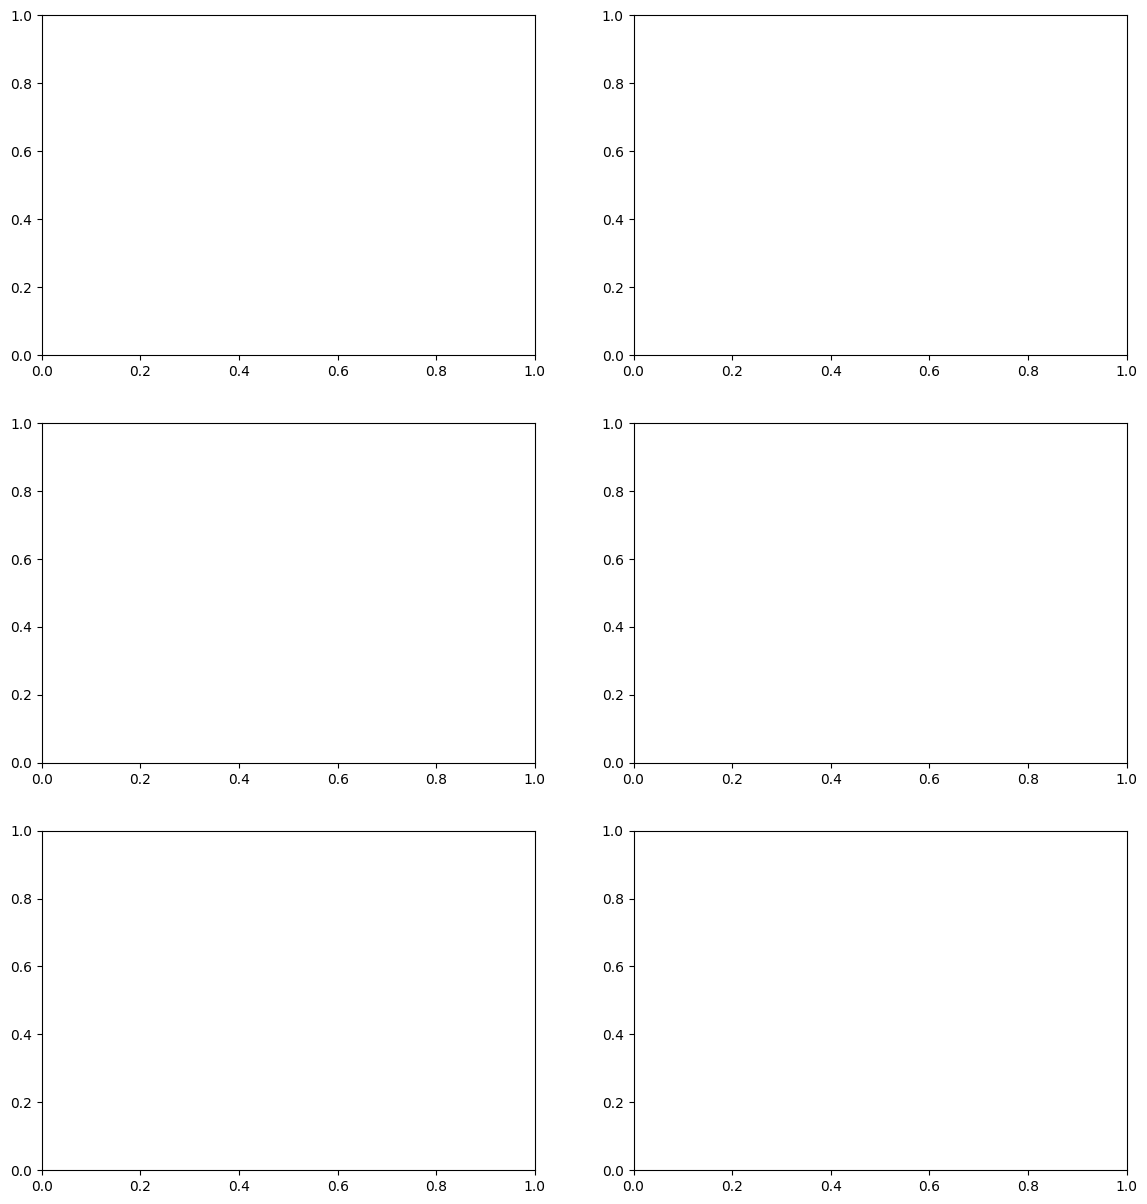

In [4]:
import matplotlib.pyplot as plt
import matplotlib
import numpy as np
import pickle

with open('dmon_attack_results1_r20.pkl', 'rb') as f:
    results1 = pickle.load(f)

# Define colors for each sigma_c value, so colors are consistent across subplots
color_map = {s: c for s, c in zip(sigma_c_values, plt.cm.viridis(np.linspace(0, 1, len(sigma_c_values))))}

metric_styles = {
    'nmi': 'dotted',
    'ecs': 'solid',
    'M1': 'dashed',
    'M2': 'dotted'
}
metric_markers = {
    'nmi': 'x',
    'ecs': 'o',
    'M1': 'o',
    'M2': 'x'
}

fig, axes = plt.subplots(len(mu_values), 2, figsize=(14, 5 * len(mu_values)))

for idx, mu in enumerate(mu_values):
    for sigma_c in sigma_c_values:
        color = color_map[sigma_c]
        
        # nmi_means = [np.mean(results1[mu][sigma_c][bb]["nmi"]) for bb in results1[mu][sigma_c].keys()]
        ecs_means = [np.mean(results1[mu][sigma_c][bb]["ecs"]) for bb in results1[mu][sigma_c].keys()]
        M1_means = [np.mean(results1[mu][sigma_c][bb]["M1"]) for bb in results1[mu][sigma_c].keys()]
        M2_means = [np.mean(results1[mu][sigma_c][bb]["M2"]) for bb in results1[mu][sigma_c].keys()]

        # ECS/NMI plot
        axes[idx, 0].plot(list(results1[mu][sigma_c].keys()), ecs_means, marker=metric_markers['ecs'], linestyle=metric_styles['ecs'],
                          color=color, label=f'ECS σ_c={sigma_c}')
        axes[idx, 0].plot(list(results1[mu][sigma_c].keys()), nmi_means, marker=metric_markers['nmi'], linestyle=metric_styles['nmi'],
                          color=color, label=f'NMI σ_c={sigma_c}')

        # M1/M2 plot
        axes[idx, 1].plot(list(results1[mu][sigma_c].keys()), M1_means, marker=metric_markers['M1'], linestyle=metric_styles['M1'],
                          color=color, label=f'M1 σ_c={sigma_c}')
        axes[idx, 1].plot(list(results1[mu][sigma_c].keys()), M2_means, marker=metric_markers['M2'], linestyle=metric_styles['M2'],
                          color=color, label=f'M2 σ_c={sigma_c}')

    axes[idx, 0].set_title(f"DICE on LFR with mu={mu}: ECS/NMI")
    axes[idx, 1].set_title(f"DICE on LFR with mu={mu}: M1/M2")
    for ax in axes[idx]:
        ax.set_xlabel("DICE Budget b (number of edges)")
        ax.set_ylabel("Score")
        ax.legend()
        ax.grid(True)

plt.tight_layout()
plt.show()


### Random features

In [93]:
G_random, data_random, true_labels = generate_lfr_graph(mu=0.5, n=1000, num_features=num_features, feature_mode='random', seed=13)
print("Graph generated with the following parameters:")
print(f"Number of nodes: {G_random.number_of_nodes()}")
print(f"Number of edges: {G_random.number_of_edges()}")
print(f"Number of communities: {len(set(true_labels))}")

target_community = [nn for nn, label in enumerate(true_labels) if label == 0]
G_target = G_random.subgraph(target_community)
num_edges_target = G_target.number_of_edges()
print(f"'Number of nodes in community 0: {len(target_community)}")
print(f"Edges in the target community: {num_edges_target}")

Graph generated with the following parameters:
Number of nodes: 1000
Number of edges: 18670
Number of communities: 33
'Number of nodes in community 0: 10
Edges in the target community: 19


In [71]:
import torch
import dmon

num_clusters = len(set(true_labels))
model = dmon.DMoN(in_channels=num_features, num_clusters=num_clusters, gcn_skip=True)

learning_rate = 0.005
weight_decay = 5e-4
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=weight_decay)

# Train the model
for epoch in range(201):
    model.train()
    optimizer.zero_grad()
    ca, loss = model(data_random.x, data_random.edge_index)
    loss.backward()
    optimizer.step()
    if epoch % 20 == 0:
        print(f"Epoch {epoch:03d} | Loss: {loss.item():.4f}")

Epoch 000 | Loss: 1.2674
Epoch 020 | Loss: 1.0044
Epoch 040 | Loss: 0.4730
Epoch 060 | Loss: 0.3052
Epoch 080 | Loss: 0.2723
Epoch 100 | Loss: 0.1862
Epoch 120 | Loss: 0.1969
Epoch 140 | Loss: 0.1836
Epoch 160 | Loss: 0.1768
Epoch 180 | Loss: 0.1864
Epoch 200 | Loss: 0.1899


In [ ]:
model.eval()
ca, _ = model(data_random.x, data_random.edge_index)
pred_labels = ca.argmax(dim=1).numpy()

# print(f"Shape of predicted labels: {pred_labels.shape}")

In [ ]:
from sklearn.metrics import normalized_mutual_info_score
from clusim.clustering import Clustering
from clusim.sim import element_sim # Element-centric similarity from A.J. Gates and YY Ahn

nmi = normalized_mutual_info_score(true_labels, pred_labels)
print(f"NMI between DMoN and LFR ground truth: {nmi:.4f}")


# Convert label lists to CluSim Clustering objects
true_clustering = Clustering().from_membership_list(true_labels)
pred_clustering = Clustering().from_membership_list(pred_labels)

# Compute element-centric similarity
ecs_sim = element_sim(true_clustering, pred_clustering)
print(f"ECS between DMoN and LFR ground truth: {ecs_sim:.4f}")


NMI between DMoN and LFR ground truth: 0.4929
ECS between DMoN and LFR ground truth: 0.3502


In [13]:
import random
import numpy as np
seed = None
random.seed(seed)
np.random.seed(seed)

print(random.sample(range(156),10))

[144, 92, 145, 7, 101, 80, 146, 84, 87, 107]
